## Introduction
This Jupyter Notebook implements polynomial models to simulate data with and without stochastic noise. It develops a Stochastic Gradient Descent algorithm to minimise the Mean Squared Error (MSE) for 1st, 3rd, and 7th-order polynomial approximations and plot diagrams. By evaluating the models' performance both within the training data and across an expanded range, the gerneralisation abilities of three models were also compared using a  3rd-order data sample.


In [ ]:
# Import essential libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style
import matplotlib as mpl

#Set default figure size
mpl.rcParams["legend.frameon"] = True
mpl.rcParams['figure.dpi']= 150

## Part 1: Function Definition and Testing

### The polynomial without noise:
$$y(x) = \sum_{i=0}^{n} \theta_i x^i $$.

### The ploynomial with noise:
$$y(x) = \sum_{i=0}^{n} \theta_i x^i + \epsilon$$



In [ ]:
def polyModel (x, theta):
  """
  Calculate the value of the polynomial without noise

  Args:
      x: a numpy array of the input x values
      theta: a numpy array of the input theta values

  Returns:
      y: a numpy array of the model y values with same shape as x
  """
  y = np.zeros(x.shape)
  for i in range(len(theta)):
    y += theta[i] * (x ** i)
  return y

def polyModelWithNoise(x,theta,sigma):
  """
  Calculate the value of the polynomial with noise

  Args:
      x: a numpy array of the input x values
      theta: a numpy array of the input theta values
      sigma: the standard deviation of the noise

  Returns:
      y_n: a numpy array of the true y values with same shape as x
  """
  y = polyModel(x, theta)
  noise = np.random.normal(0, sigma, size = x.shape)
  y_n = y + noise
  return y_n

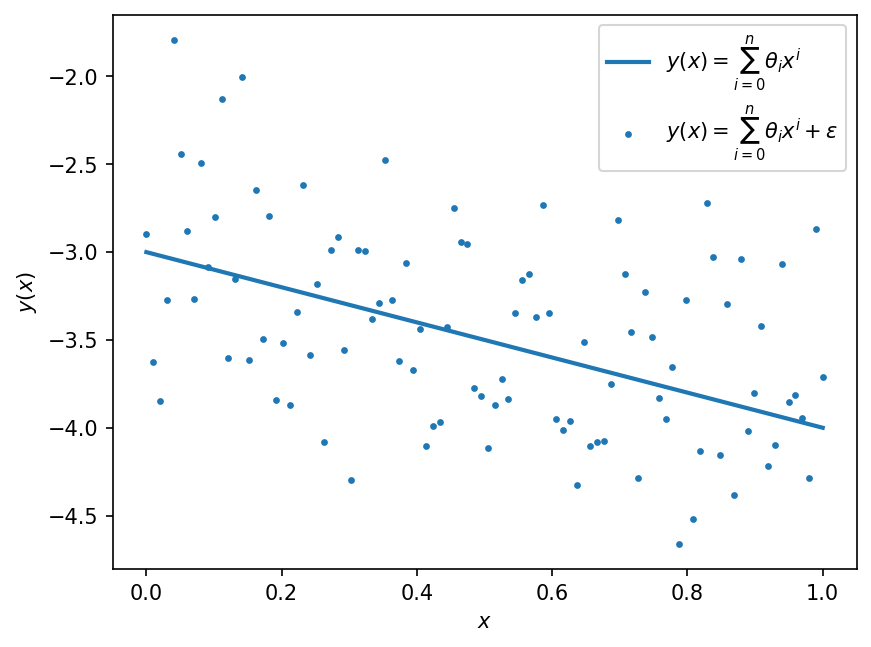

In [ ]:
# Generate 100 x values and set theta values
x = np.linspace(0, 1, 100)
theta = np.array([-3, -1])

# Plot the polyModel values as a line and the polyModelWithNoise as data points using a value of sigma=0.5
fig, ax = plt.subplots()
ax.plot(x, polyModel(x, theta), linewidth =2, label = r"$y(x) = \sum_{i=0}^{n} \theta_i x^i$")
ax.scatter(x, polyModelWithNoise(x, theta, 0.5), s = 5, label = r"$y(x) = \sum_{i=0}^{n} \theta_i x^i + \epsilon$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y(x)$")
ax.legend()


##Part 2: Constriuction of Gradient Descent Algorithm




In [ ]:
def polyGradient(x, theta):
  """
  Calculate the gradient matrix, the row is sample x value and column is the parameter theta

  Args:
      x: a numpy array of the input x values
      theta: a numpy array of the input theta values

  Returns:
      output: a (len(x), len(theta)) dimensional matrix, the derivatives of the polynomial with respect to theta
  """
  output = np.zeros((len(x), len(theta))) # initialise the matrix

  for i in range(len(x)):
    for j in range(len(theta)):
      output[i, j] = x[i]**j

  return output

In [ ]:
def get_mse(y_model, y_true):
  """
  Calculate the mean squared error between y_model and Y_true

  Args:
      y_model: an array of predicted values generated by the model.
      y_true: an array of the actual (ground truth) data values.

  Returns:
      mse: The mean squared error value
  """

  mse = np.average((y_model - y_true) ** 2) # Calculate the mean squared error

  return mse

def update_theta(x, theta_start, y_model, y_true, eta):
  """
  Update the polynomial parameters using the Gradient Descent optimization rule.

    This function calculates the gradient of the Mean Squared Error (MSE)
    and updates the parameters (theta) in the direction
    that minimizes the error.

    Args:
        x: Input values of sample.
        theta_start: current parameter vector of shape .
        y_model: predicted values from the current model .
        y_true: actual true values.
        eta: The learning rate, controlling the step size of the update.

    Returns:
        theta_new: The updated parameter vector array after one gradient step.
  """

  error = y_model - y_true # Calculate the error
  grad_y = polyGradient(x, theta_start) # get the matrix of partial derivatives with respect ot theta

  n = len(x)
  average_grad_y = 2/n * np.dot(grad_y.T, error) # Calculate the average gradient of MSE cost function

  theta_new = theta_start - eta * average_grad_y # apply the update rule of gradient descent

  return theta_new

def stochastic_grad_desc(theta_start, theta_true, eta, sigma, numStep, numSample):
  """
  Build a stochastic descent algorithm

  Args:
      theta_start: initial guess for the polynomial coefficients
      theta_true: the true coefficients used to generate data
      eta: learning rate for the gradient update
      sigma: standard deviation of the Gaussian noise added to the data
      numStep: total number of iterations (steps) to perform
      numSample: the number of data points sampled in each iteration

  Returns:
      mse_path: an array of the MSE values history
      theta_path: an array of the theta values history
  """
  # Initialise the current theta and tracking array
  theta = np.array(theta_start).copy()
  theta_path = np.zeros((numStep + 1, len(theta_start)))
  theta_path[0] = theta
  mse_path = np.zeros(numStep)

  for i in range(numStep):
    x_sample = np.random.uniform(0, 1, numSample) # randomly sample x values from a uniform distribution [0, 1)
    y_model = polyModel(x_sample, theta) # generate model predictions using current theta
    y_true = polyModelWithNoise(x_sample, theta_true, sigma) # generate the true data using the true theta
    mse_path[i] = get_mse(y_model, y_true) # record the current mse
    theta = update_theta(x_sample, theta, y_model, y_true, eta) # update the theta
    theta_path[i+1] = theta #record the theta

  return mse_path, theta_path


### Following the methods outlined above, I will plot the results. This includes the Mean Squared Error (MSE) versus step numbers for the 1st-order data, as well as a comparative plot of the MSE across three models (1st, 3rd, and 7th-order polynomials) for the 3rd-order data.

/tmp/ipython-input-3036805553.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


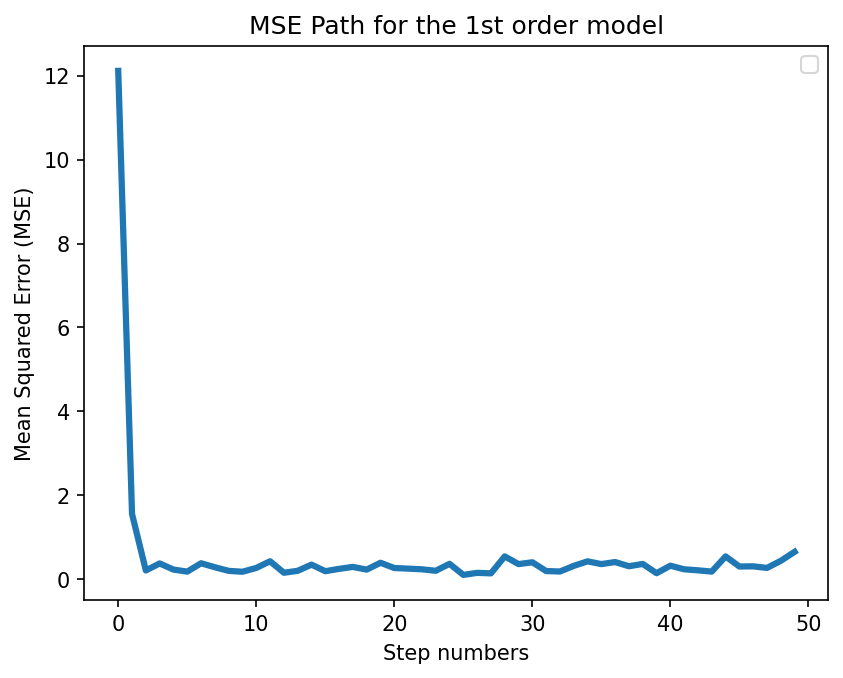

In [ ]:
theta_start = np.array([-1, 1])
theta_true = np.array([-3, -1]) # 1st order data
numSample = 10 # number of samples
numStep = 50 # number of steps
eta = 0.5 # the learning rate (step length)
sigma = 0.5 # standard deviation

mse_path_1, theta_path_1 = stochastic_grad_desc(theta_start, theta_true, eta, sigma, numStep, numSample)

# Plot MSE agianst step numbers
fig, ax = plt.subplots()
ax.plot(range(numStep), mse_path_1, linewidth = 3)
ax.set_xlabel('Step numbers')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('MSE Path for the 1st order model')

plt.legend()

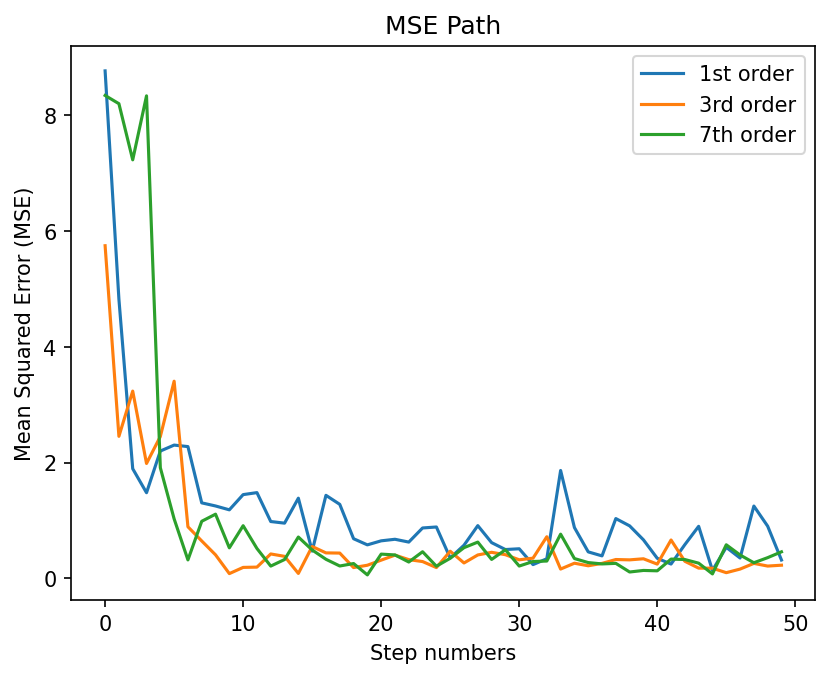

In [ ]:
# initialisation
theta_start_1st = np.array([0, 0]) # up to x^1
theta_start_3rd = np.array([0, 0, 0, 0]) # up to x^3
theta_start_7th = np.array([0, 0, 0, 0, 0, 0, 0, 0]) # up to x^7
theta_true = np.array([-1, 2, 3, 2])
numSample = 10 # number of samples
numStep = 50 # number of iteration steps
eta = 0.5 # the learning rate
sigma = 0.5 # the standard deviation

# fit the data with polynomials
mse_path_1, theta_path_1 = stochastic_grad_desc(theta_start_1st, theta_true, eta, sigma, numStep, numSample)
mse_path_3, theta_path_3 = stochastic_grad_desc(theta_start_3rd, theta_true, eta, sigma, numStep, numSample)
mse_path_7, theta_path_7 = stochastic_grad_desc(theta_start_7th, theta_true, eta, sigma, numStep, numSample)

# plot the MSE against step numbers for 1st, 3rd and 7th order polynomials
fig, ax = plt.subplots()
ax.plot(range(numStep), mse_path_1, label = '1st order')
ax.plot(range(numStep), mse_path_3, label = '3rd order')
ax.plot(range(numStep), mse_path_7, label = '7th order')
ax.set_xlabel('Step numbers')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('MSE Path')

plt.legend()



## Part 3: Models Comparison

In [ ]:
# Collect data sets
x_data = np.linspace(-0.5, 1.5, 100)
y_data = polyModelWithNoise(x_data, theta_true, sigma)

# get trained theta values for models
trained_theta_1 = theta_path_1[-1]
trained_theta_3 = theta_path_3[-1]
trained_theta_7 = theta_path_7[-1]

# get calculated y values by applying trained theta value of each model
y_data_1 = polyModel(x_data, trained_theta_1)
y_data_3 = polyModel(x_data, trained_theta_3)
y_data_7 = polyModel(x_data, trained_theta_7)

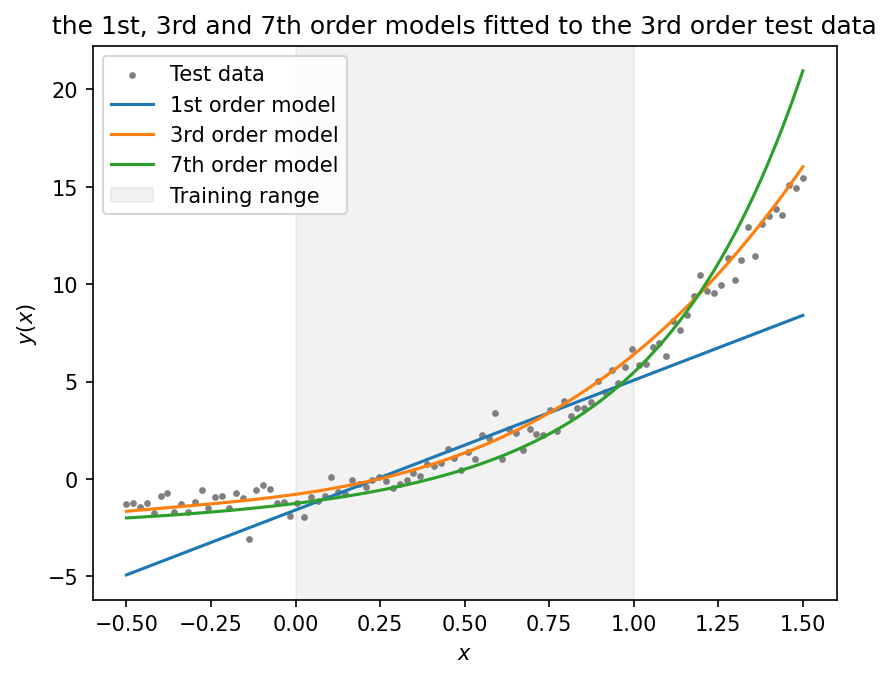

In [ ]:
# Plot the models fitting the data set
fig, ax = plt.subplots()
ax.scatter(x_data, y_data, s=5, c='grey', label = 'Test data')
ax.plot(x_data, y_data_1, label = '1st order model')
ax.plot(x_data, y_data_3, label = '3rd order model')
ax.plot(x_data, y_data_7, label = '7th order model')
ax.axvspan(0, 1, alpha = 0.1, color = 'grey', label = 'Training range') # highlight the training range
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y(x)$')
ax.set_title('the 1st, 3rd and 7th order models fitted to the 3rd order test data')

ax.legend()

###Comments on Generalisation of the Three Models
According to the plot, the models perform differently across the $x$ range. Within the training range ($0 \le x \le 1$), the 3rd and 7th order models fit the data closely, whereas the 1st order model shows a clear deviation, indicating underfitting as it fails to capture the underlying curvature.

Outside the training range, the 7th order model diverges sharply from the test data, indicating overfitting as the model captures noise rather than the true trend. In contrast, the 3rd order model maintains a consistent fit across the given range. Overall, the 3rd order model demonstrates the best generalization ability.